In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import json
import requests

# Task 1: Load Data From CSV

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape


(891, 12)

In [4]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Observation:

The dataset contains passenger information from Titanic.
Age and Cabin contain missing values.
The dataset contains both numerical and categorical columns.

# Task 2 - Load Data From JSON

In [8]:
products = [
    {"id":1,"name":"Laptop","price":50000},
    {"id":2,"name":"Phone","price":20000},
    {"id":3,"name":"Tablet","price":15000}
]

with open("sample.json","w") as f:
    json.dump(products,f)

In [9]:
json_df = pd.read_json("sample.json")

json_df

,id,name,price
0,1,Laptop,50000
1,2,Phone,20000
2,3,Tablet,15000


# Task 3 - SQLite Database

In [10]:
conn = sqlite3.connect("sample.db")

cursor = conn.cursor()

In [11]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees(
id INTEGER,
name TEXT,
department TEXT,
salary INTEGER
)
""")

In [12]:
employees = [
(1,"John","IT",50000),
(2,"Alice","HR",45000),
(3,"Bob","Finance",60000),
(4,"Emma","IT",70000),
(5,"David","Sales",55000)
]

cursor.executemany(
    "INSERT INTO employees VALUES(?,?,?,?)",
    employees
)

conn.commit()

In [13]:
emp_df = pd.read_sql_query(
    "SELECT * FROM employees",
    conn
)

emp_df

,id,name,department,salary
0,1,John,IT,50000
1,2,Alice,HR,45000
2,3,Bob,Finance,60000
3,4,Emma,IT,70000
4,5,David,Sales,55000
5,1,John,IT,50000
6,2,Alice,HR,45000
7,3,Bob,Finance,60000
8,4,Emma,IT,70000
9,5,David,Sales,55000


# Task 4 - TMDB API

In [ ]:
api_key = "***********************************"

url = f"https://api.themoviedb.org/3/movie/popular?api_key={api_key}"

response = requests.get(url)

movies = response.json()["results"]

movies[:2]

[{'adult': False,
  'backdrop_path': '/4k99kV4R1bbbrsnjR205v91Xbin.jpg',
  'genre_ids': [27, 53],
  'id': 1339713,
  'title': 'Obsession',
  'original_language': 'en',
  'original_title': 'Obsession',
  'overview': 'After breaking the mysterious "One Wish Willow" to win his crush\'s heart, a hopeless romantic finds himself getting exactly what he asked for but soon discovers that some desires come at a dark, sinister price.',
  'popularity': 817.0684,
  'poster_path': '/bRwnj8WEKBCvmfeUNOukJPwB43K.jpg',
  'release_date': '2026-05-13',
  'softcore': False,
  'video': False,
  'vote_average': 7.9,
  'vote_count': 707},
 {'adult': False,
  'backdrop_path': '/oPsRr7AfNLw6XaPuMpvkWK0bIUA.jpg',
  'genre_ids': [28, 18],
  'id': 1057265,
  'title': 'Peddi',
  'original_language': 'te',
  'original_title': 'పెద్ది',
  'overview': 'In 1980s rural Andhra Pradesh, a spirited villager unites his community through sports to defend their pride against a powerful rival.',
  'popularity': 764.3619,
  '

In [15]:
movie_data = []

for movie in movies:

    movie_data.append({
        "title": movie["title"],
        "release_date": movie["release_date"],
        "rating": movie["vote_average"],
        "popularity": movie["popularity"]
    })

movies_df = pd.DataFrame(movie_data)

movies_df.head()

,title,release_date,rating,popularity
0,Obsession,2026-05-13,7.900,817.0684
1,Peddi,2026-06-03,6.453,764.3619
2,Hai Jawani Toh Ishq Hona Hai,2026-06-04,5.400,548.4534
3,The Unknown Man,2021-10-16,8.063,672.0008
4,Michael,2026-04-22,8.500,460.9936


In [16]:
movies_df.to_csv(
    "tmdb_movies.csv",
    index=False
)

# Task 5 - Understanding Data

In [17]:
print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Task 6 - Data Cleaning

In [18]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [19]:
df.columns = (
    df.columns
      .str.lower()
      .str.replace(" ","_")
)

df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Task 7 - Feature Preparation

In [20]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex","embarked"],
    drop_first=True
)

df_encoded.head()

,passengerid,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,sex_male,embarked_Q,embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True


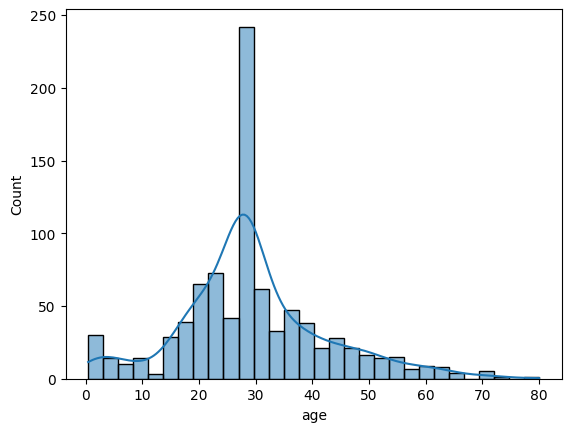

In [21]:
sns.histplot(df["age"], kde=True)

plt.show()

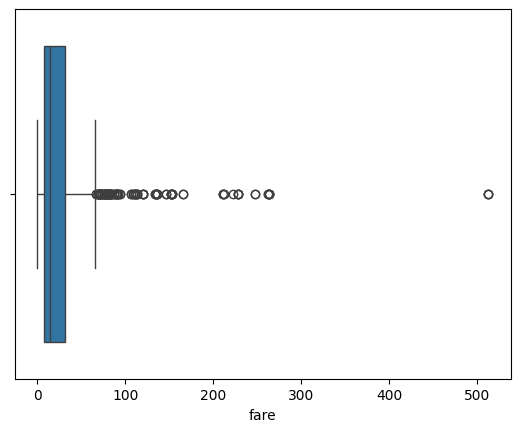

In [22]:
sns.boxplot(x=df["fare"])

plt.show()

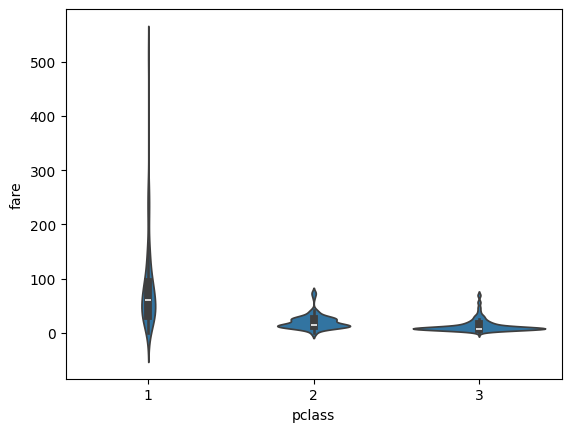

In [23]:
sns.violinplot(
    data=df,
    x="pclass",
    y="fare"
)

plt.show()

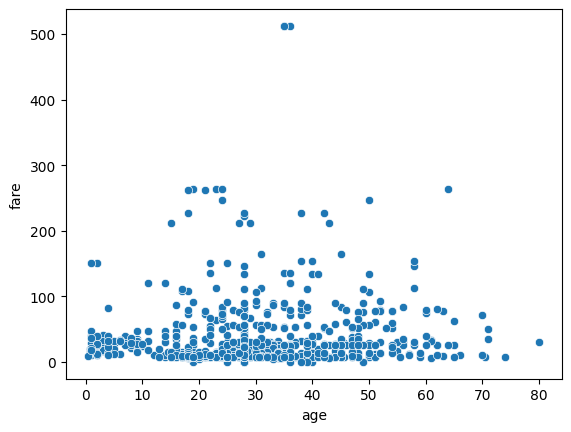

In [24]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare"
)

plt.show()

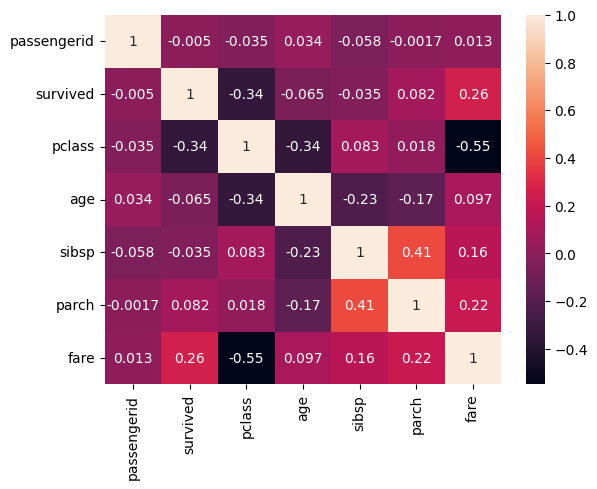

In [25]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True
)

plt.show()

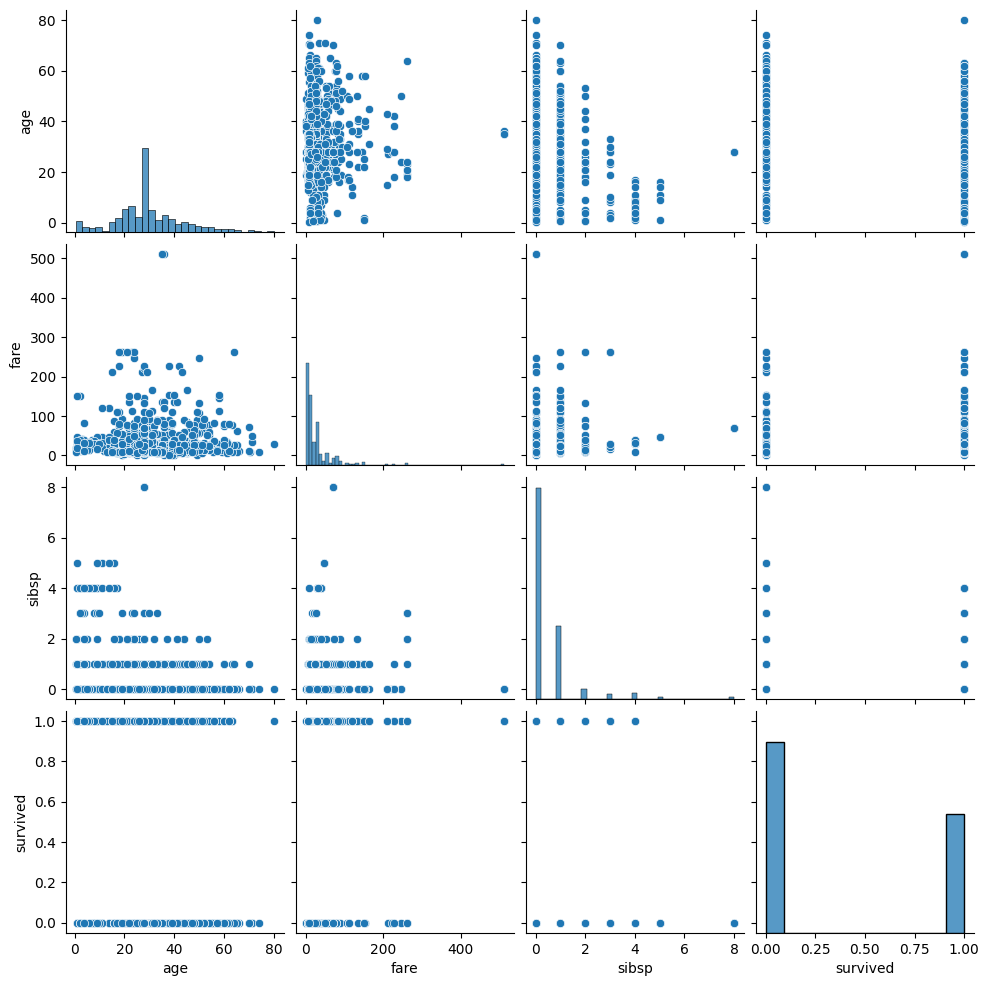

In [26]:
sns.pairplot(
    df[
        ["age","fare","sibsp","survived"]
    ]
)

plt.show()

# Insights

1. Most passengers were between 20 and 40 years old.

2. Age contained missing values and was cleaned using median imputation.

3. Fare distribution is highly right-skewed.

4. Several extreme fare outliers exist.

5. First-class passengers generally paid higher fares.

6. Female passengers had a higher survival rate.

7. The dataset contains both numerical and categorical features.

8. Correlation between numerical variables is generally weak.